In [7]:
import numpy as np
import pandas as pd

npz = np.load("bodmas.npz", allow_pickle=True)
X = npz["X"]
y = npz["y"]

meta = pd.read_csv("bodmas_metadata.csv")
cats = pd.read_csv("bodmas_malware_category.csv")

# Standardize column names
meta = meta.rename(columns={"sha": "sha256"})
cats = cats.rename(columns={"category": "malware_category"})

# Merge metadata with category labels
df = meta[["sha256", "timestamp", "family"]].copy()
df = df.merge(cats[["sha256", "malware_category"]], on="sha256", how="left")

# Fill missing labels with benign
df["malware_category"] = df["malware_category"].fillna("benign")

# Attach features
feature_df = pd.DataFrame(X)
feature_df["label"] = df["malware_category"].values

print("Feature shape:", X.shape)
print("Merged label shape:", df.shape)
print("Unique labels:", df["malware_category"].nunique())
print("\nClass counts:")
print(df["malware_category"].value_counts())

Feature shape: (134435, 2381)
Merged label shape: (134435, 4)
Unique labels: 15

Class counts:
malware_category
benign                77142
trojan                29972
worm                  16697
backdoor               7331
downloader             1031
ransomware              821
dropper                 715
informationstealer      448
virus                   192
pua                      29
cryptominer              20
p2p-worm                 16
exploit                  12
trojan-gamethief          6
rootkit                   3
Name: count, dtype: int64


Train shape: (107548, 2381)
Test shape: (26887, 2381)

Training Random Forest...

Random Forest Accuracy: 0.9700598802395209

Random Forest Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.94      0.97      0.95      1466
            benign       0.99      1.00      0.99     15428
        downloader       0.93      0.82      0.87       206
           dropper       0.80      0.79      0.79       143
informationstealer       0.92      0.79      0.85        90
             other       0.71      0.29      0.42        17
        ransomware       0.95      0.86      0.90       164
            trojan       0.96      0.92      0.94      5995
             virus       1.00      0.82      0.90        39
              worm       0.93      0.95      0.94      3339

          accuracy                           0.97     26887
         macro avg       0.91      0.82      0.86     26887
      weighted avg       0.97      0.97      0.97     2

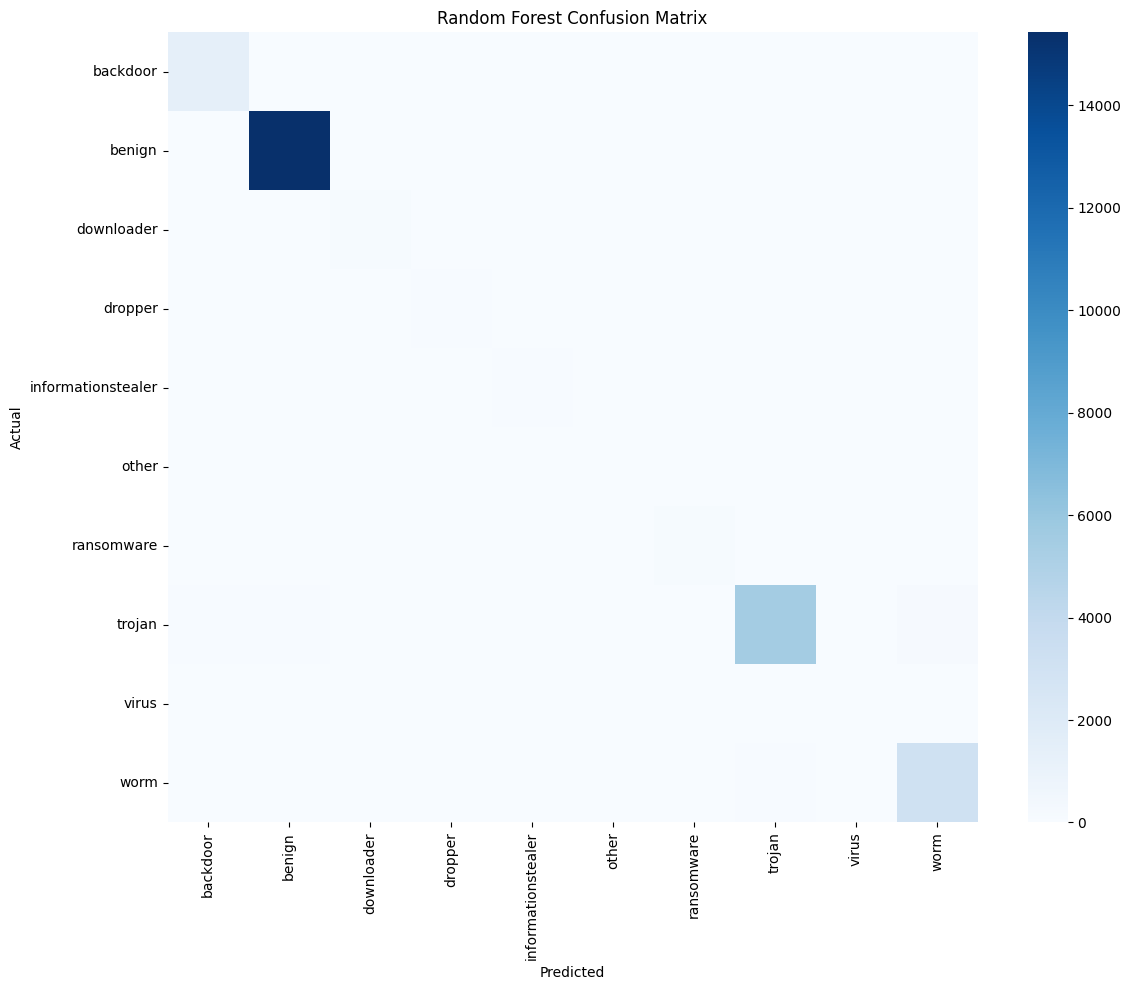

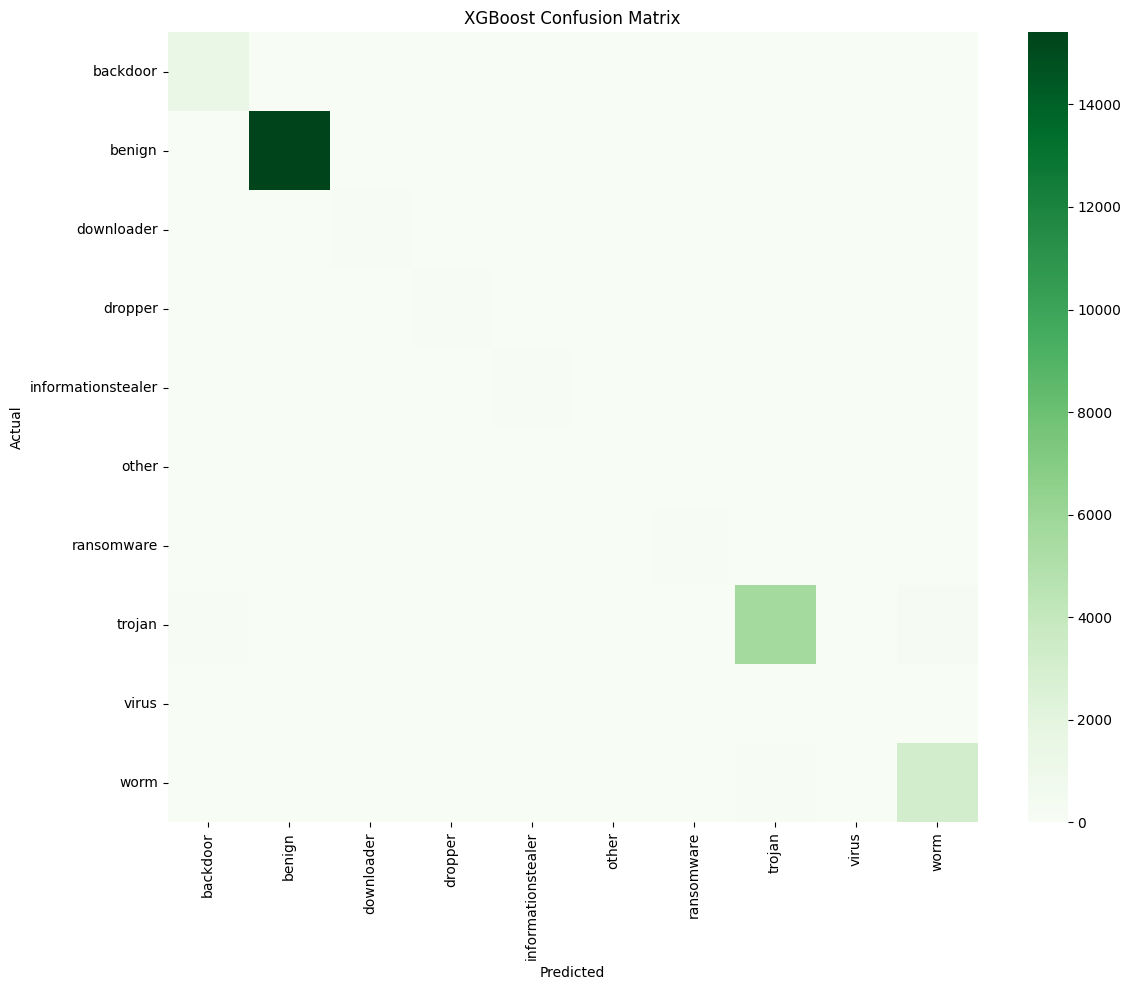

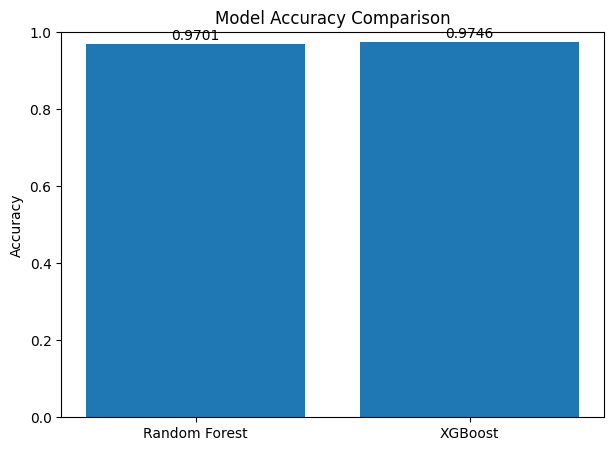

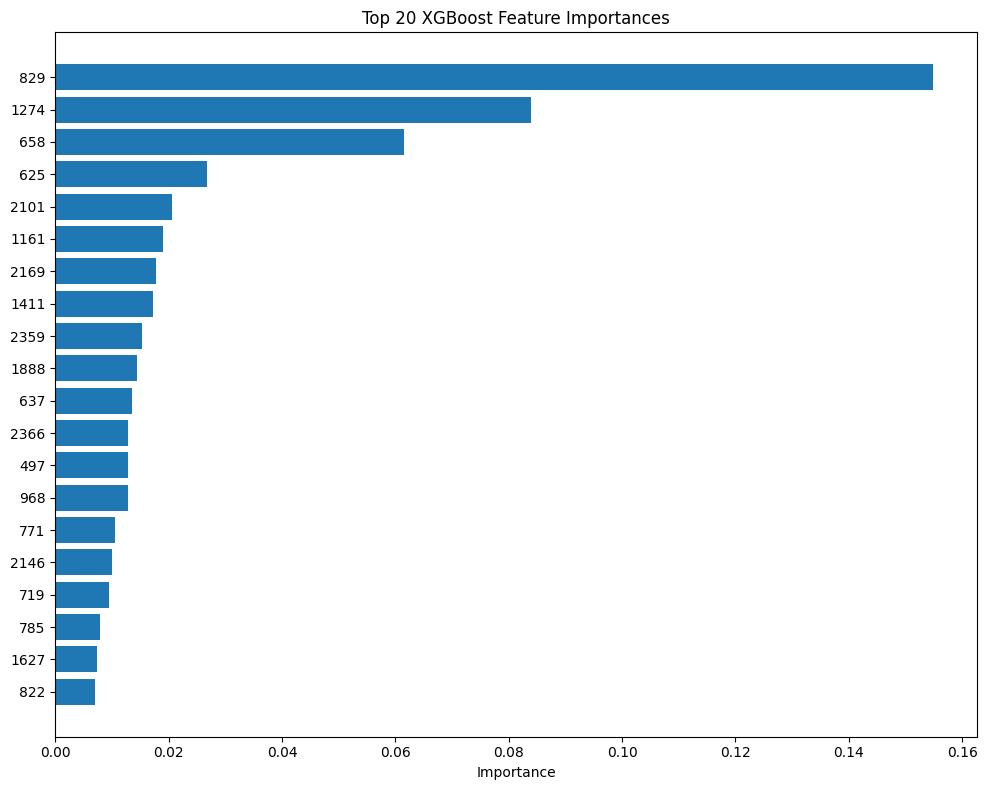

In [9]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------

data = np.load("bodmas.npz")

X = data["X"]
y_binary = data["y"]

metadata = pd.read_csv("bodmas_metadata.csv")
category = pd.read_csv("bodmas_malware_category.csv")

# ---------------------------------------------------
# MERGE LABELS
# ---------------------------------------------------

merged = metadata.merge(
    category,
    left_on="sha",
    right_on="sha256",
    how="left"
)

merged["category"] = merged["category"].fillna("benign")

# ---------------------------------------------------
# HANDLE SMALL CLASSES
# ---------------------------------------------------

min_samples = 50

class_counts = merged["category"].value_counts()

small_classes = class_counts[class_counts < min_samples].index

merged["category"] = merged["category"].replace(
    small_classes,
    "other"
)

# ---------------------------------------------------
# LABEL ENCODING
# ---------------------------------------------------

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(merged["category"])

# ---------------------------------------------------
# TRAIN TEST SPLIT
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ===================================================
# RANDOM FOREST
# ===================================================

print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)

print("\nRandom Forest Accuracy:", rf_acc)

print("\nRandom Forest Classification Report:")
print(
    classification_report(
        y_test,
        rf_preds,
        target_names=label_encoder.classes_
    )
)

# ===================================================
# XGBOOST
# ===================================================

print("\nTraining XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_preds)

print("\nXGBoost Accuracy:", xgb_acc)

print("\nXGBoost Classification Report:")
print(
    classification_report(
        y_test,
        xgb_preds,
        target_names=label_encoder.classes_
    )
)

# ===================================================
# CONFUSION MATRICES
# ===================================================

rf_cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(12, 10))

sns.heatmap(
    rf_cm,
    annot=False,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ---------------------------------------------------

xgb_cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(12, 10))

sns.heatmap(
    xgb_cm,
    annot=False,
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ===================================================
# ACCURACY COMPARISON GRAPH
# ===================================================

models = ["Random Forest", "XGBoost"]
accuracies = [rf_acc, xgb_acc]

plt.figure(figsize=(7, 5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.4f}", ha="center")

plt.show()

# ===================================================
# FEATURE IMPORTANCE (XGBOOST)
# ===================================================

importance = xgb_model.feature_importances_

top_n = 20

indices = np.argsort(importance)[-top_n:]

plt.figure(figsize=(10, 8))

plt.barh(
    range(top_n),
    importance[indices]
)

plt.yticks(
    range(top_n),
    indices
)

plt.xlabel("Importance")
plt.title("Top 20 XGBoost Feature Importances")

plt.tight_layout()
plt.show()